In [4]:
import random
import datetime
import json

levels = ["INFO", "INFO", "INFO", "WARN", "ERROR"]
endpoints = ["/api/v1/login", "/api/v1/data", "/api/v1/order", "/api/v1/logout"]
messages = ["User authenticated", "Database query successful", "Connection timed out", "Invalid token"]

def generate_logs(filename="system_logs.txt", count=50):
    with open(filename, "w") as f:
        for _ in range(count):
            timestamp = (datetime.datetime.now() - datetime.timedelta(minutes=random.randint(0, 1000))).strftime('%Y-%m-%d %H:%M:%S')
            level = random.choice(levels)
            endpoint = random.choice(endpoints)
            msg = random.choice(messages)
            
            # Mix formats: 80% String, 20% JSON
            if random.random() > 0.2:
                f.write(f"[{timestamp}] {level}: {msg} at {endpoint}\n")
            else:
                log_json = {"ts": timestamp, "lvl": level, "msg": msg, "path": endpoint}
                f.write(json.dumps(log_json) + "\n")

generate_logs()


In [3]:
#We use regex for the string logs and the json library for the structured logs.
import re
import pandas as pd

def parse_logs(file_path):
    parsed_data = []
    # Regex for [timestamp] LEVEL: message at endpoint
    log_pattern = re.compile(r'\[(?P<ts>.*?)\] (?P<lvl>\w+): (?P<msg>.*?) at (?P<path>.*)')

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith('{'): # Detect JSON
                parsed_data.append(json.loads(line))
            else:
                match = log_pattern.match(line)
                if match:
                    parsed_data.append(match.groupdict())
    
    return pd.DataFrame(parsed_data)

df = parse_logs("system_logs.txt")
df['ts'] = pd.to_datetime(df['ts'])

In [4]:
df


,ts,lvl,msg,path
0,2026-03-30 08:42:56,ERROR,User authenticated,/api/v1/login
1,2026-03-30 01:59:56,WARN,Database query successful,/api/v1/logout
2,2026-03-30 02:41:56,ERROR,Database query successful,/api/v1/order
3,2026-03-30 12:19:56,ERROR,Connection timed out,/api/v1/data
4,2026-03-30 03:58:56,INFO,Connection timed out,/api/v1/order
5,2026-03-29 21:26:56,INFO,Database query successful,/api/v1/login
6,2026-03-30 01:41:56,INFO,Database query successful,/api/v1/order
7,2026-03-30 07:54:56,ERROR,User authenticated,/api/v1/data
8,2026-03-30 05:54:56,INFO,Connection timed out,/api/v1/order
9,2026-03-29 20:37:56,ERROR,Database query successful,/api/v1/data


In [5]:
# Using pandas, we can quickly group errors and identify "hotspots" in the system.
#Frequency of Log Levels
level_counts = df['lvl'].value_counts()

# Identify most problematic endpoints
error_hotspots = df[df['lvl'] == 'ERROR']['path'].value_counts()

print("Log Distribution:\n", level_counts)
print("\nTop Error Locations:\n", error_hotspots)

Log Distribution:
 lvl
INFO     28
WARN     12
ERROR    10
Name: count, dtype: int64

Top Error Locations:
 path
/api/v1/login    4
/api/v1/order    3
/api/v1/data     3
Name: count, dtype: int64


In [6]:
#A simple rule engine can trigger alerts if the error rate exceeds a specific threshold (e.g., more than 5 errors in a 10-minute window).
def check_alerts(df, threshold=10):
    error_df = df[df['lvl'] == 'ERROR']
    # Resample to 10-minute bins
    error_rate = error_df.set_index('ts').resample('10T').count()['lvl']
    
    alerts = error_rate[error_rate > threshold]
    if not alerts.empty:
        print(f"🚨 ALERT: High error volume detected at {alerts.index[-1]}")

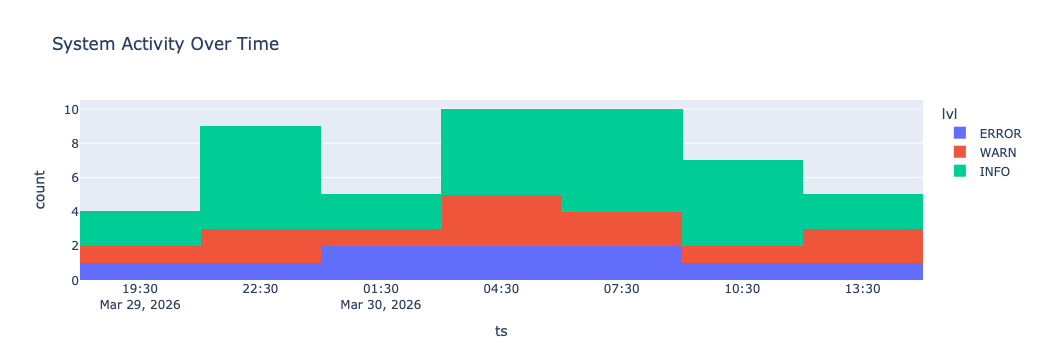

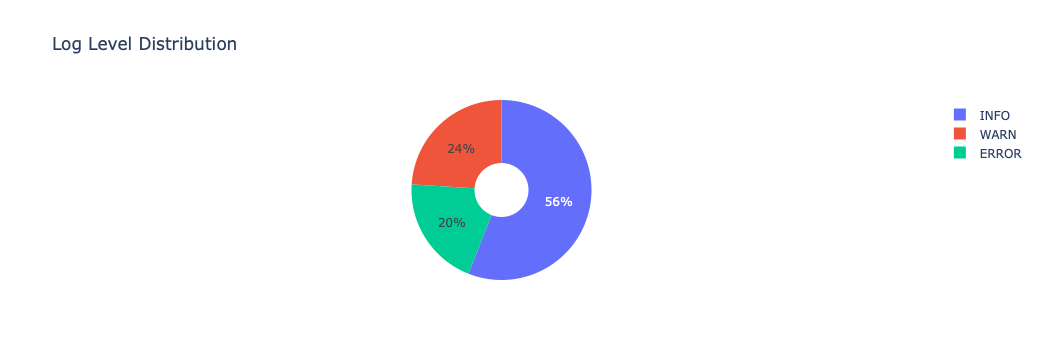

In [7]:
#Using plotly, you can create an interactive view of system health
import plotly.express as px

def create_dashboard(df):
    # Time-series of logs
    time_plot = px.histogram(df, x="ts", color="lvl", title="System Activity Over Time")
    
    # Pie chart of log levels
    pie_plot = px.pie(df, names='lvl', title="Log Level Distribution", hole=0.3)
    
    time_plot.show()
    pie_plot.show()

create_dashboard(df)